In [1175]:
import pytesseract as tess
from pytesseract import Output
from PIL import Image
import cv2 as cv
import matplotlib.pyplot as plt
from dns.name import empty
from shapely.predicates import is_empty

In [1176]:
tess.pytesseract.tesseract_cmd = "C:/Program Files/Tesseract-OCR/tesseract.exe"

In [1177]:
image = cv.imread("./notebook/images/OCR_persian_text3.png", 0)
image_rgb = cv.imread("./notebook/images/OCR_persian_text3.png")

In [1178]:
img_blur = cv.medianBlur(image, 1)
_, image_thresh = cv.threshold(img_blur, 150, 255, cv.THRESH_BINARY)

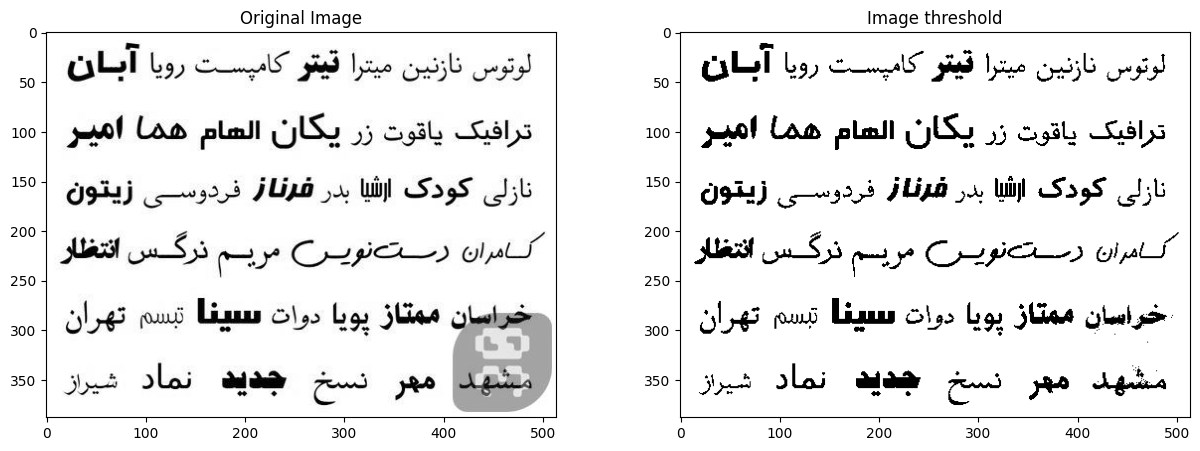

In [1179]:
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.title("Original Image")
plt.imshow(image, cmap="gray")
plt.subplot(122)
plt.title("Image threshold")
plt.imshow(image_thresh, cmap="gray")
plt.show()

In [1180]:
img_text = tess.image_to_string(image_thresh, lang="fas")
text_boxes = tess.image_to_boxes(image_thresh, lang="fas")

In [1181]:
print(img_text)

لوتوس نازنین میترا قیقو کامپست رویا آبان
ترافیک یاقوت زر یکان السام هما امیر
نازلی کودک ایا بدر قفا فردوسی زیتون
کامران رست‌نوین مرسم نرگس انتظار
خراسان ممتاز پویا درات سیفا بسم تهران

مشهد مر نسخ جدید_ نماد شیرز



### Draw a rectangle around each letter

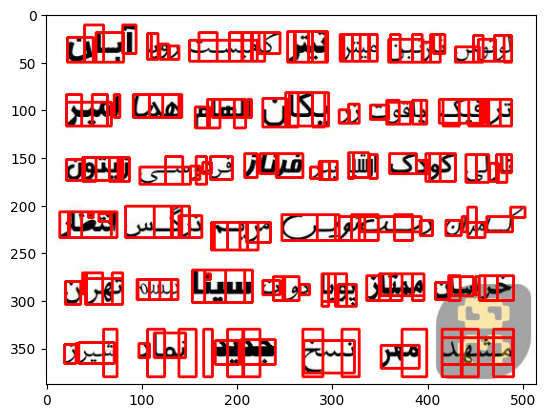

In [1182]:
h, w, c = image_rgb.shape
img_boxes = image_rgb.copy()
for box in text_boxes.split("\n"):
    box = box.split(" ")
    if not box[0]:
        break
    x1 = int(box[1])
    y1 = int(box[2])
    x2 = int(box[3])
    y2 = int(box[4])
    cv.rectangle(img_boxes, (x1, h - y1), (x2, h - y2), (0, 0, 255), 2)
plt.imshow(img_boxes[..., ::-1])

In [1183]:
text_data = tess.image_to_data(image_thresh, lang="fas", output_type=Output.DICT)
text_data

{'level': [1,
  2,
  3,
  4,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  4,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  4,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  4,
  5,
  5,
  5,
  5,
  5,
  4,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  2,
  3,
  4,
  5,
  5,
  5,
  5,
  5,
  5],
 'page_num': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'block_num': [0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2],
 'par_num': [0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  

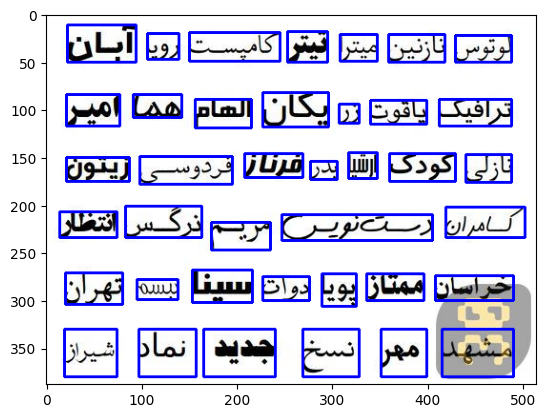

In [1184]:
image_data = image_rgb.copy()
for index, text in enumerate(text_data["text"]):
    if not text:
        continue
    x1 = int(text_data["left"][index])
    y1 = int(text_data["top"][index])
    x2 = x1 + int(text_data["width"][index])
    y2 = y1 + int(text_data["height"][index])
    cv.rectangle(image_data, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.imshow(image_data[...,::-1])
plt.show()

## Detect persian text